             id          name                              fullName  \
0         adams         Adams                                 Adams   
1           afm           AFM      Alex von Falkenhausen Motorenbau   
2           ags           AGS  Automobiles Gonfaronnaises Sportives   
3    alfa-romeo    Alfa Romeo                     Alfa Romeo Racing   
4  alfa-special  Alfa Special                          Alfa Special   

                  countryId  bestChampionshipPosition  \
0  united-states-of-america                       NaN   
1                   germany                       NaN   
2                    france                      11.0   
3                     italy                       6.0   
4              south-africa                       NaN   

   bestStartingGridPosition  bestRaceResult  bestSprintRaceResult  \
0                      17.0            27.0                   NaN   
1                       9.0             9.0                   NaN   
2                      

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5776/726969960.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


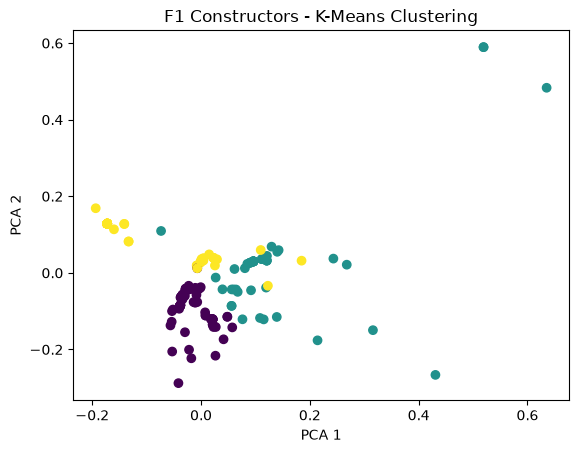

In [1]:
# F1 Constructors: NLP + K-Means

import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("f1db-constructors.csv")
print(df.head())
print(df.columns)

# Select text columns
text_cols = df.select_dtypes(include="object").columns

# Combine text columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# Clean text
df["text"] = df["text"].str.lower()
df["text"] = df["text"].apply(lambda x: re.sub(r"[^a-z\s]", " ", x))

# NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["text"])

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# Show results
print("\nCluster Results:")
print(df[["text", "cluster"]])

# PCA for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("F1 Constructors - K-Means Clustering")
plt.show()